# GNN approach for characterizing flash onset (knee point value) of various materials

**This Jupyter notebook explores the performance of a simple Graphical Neural Network model on the small dataset of flash onset values as a proof of concept to shows a graphical model can be effective in generalizing flash onset behaviors. We aim to verify such hypothesis through simple graph neural network and a arbitrary constructions.**

The dataset contains below feature columns:
1. Material Type: the specific material type (eg. Al2O3, ZrO2, YSZ)
2. Electric Field: the magnitude of the electric field applied during the process.
3. Flash Onset values (Temperature, Power Density Dissipation): The critical point at which flash sintering occurs, referred as "knee point". 

### **Findings**

After training the model, we observed:
- **Model Accuracy**: After training completion, the model scores above 80% on training datset and around 80% on testing dataset
- **Loss Function Converges**: The plot of the loss function converges during training, indicating the model is learning and actively improving based on the given data.

**Conclusion**: Based on these observations, we conclude that GNN is effective at handling relationships in flash sintering process. Graphical Neural Network can be effective in learning the relationships between flash onset value with respect to their parameters. We will continue on the GNN foundation model approach.


Import packages

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scripts.gnn import KneePointGCN, train, visualize_graph, plot_losses

load data and create feature matrix

**Dataset is loaded by treating ZrO2 and YSZ as different material types**

In [3]:
data_df = pd.read_csv('data/master_dataframe.csv')
print(pd.get_dummies(data_df['Material']))
data_df = pd.concat([data_df, pd.get_dummies(data_df['Material']).astype(float)], axis=1)

node_features = []
node_labels = []

for material, group_df in data_df.groupby('Material'):

    group_df = group_df.sort_values('Electric_Field(V/cm)').reset_index(drop=True)
    
    sub_node_features = group_df[['Al2O3', 'BaTiO3', 'CoMnO4', 'SiC', 'SrTiO3',
       'TiO2', 'Y2O3', 'YSZ', 'ZrO2', 'Electric_Field(V/cm)']].values
       
    sub_node_labels = group_df[['Knee_Temp(1000/T)', 'Knee_PW(mW/mm^3)']].values

    node_features.append(sub_node_features)
    node_labels.append(sub_node_labels)

node_features = np.concatenate(node_features, axis=0)
node_labels = np.concatenate(node_labels, axis=0)
    
print(node_features.shape)
print(node_labels.shape)


    Al2O3  BaTiO3  CoMnO4    SiC  SrTiO3   TiO2   Y2O3    YSZ   ZrO2
0    True   False   False  False   False  False  False  False  False
1    True   False   False  False   False  False  False  False  False
2   False    True   False  False   False  False  False  False  False
3   False    True   False  False   False  False  False  False  False
4   False    True   False  False   False  False  False  False  False
5   False    True   False  False   False  False  False  False  False
6   False   False    True  False   False  False  False  False  False
7   False   False    True  False   False  False  False  False  False
8   False   False    True  False   False  False  False  False  False
9   False   False    True  False   False  False  False  False  False
10  False   False   False   True   False  False  False  False  False
11  False   False   False  False    True  False  False  False  False
12  False   False   False  False    True  False  False  False  False
13  False   False   False  False  

split dataset into train, validation and test dataset (64,16,20) and normalize

In [4]:
train_features, test_features, train_labels, test_labels = train_test_split(node_features, node_labels, test_size=0.2, shuffle=True, random_state=5)
train_features, val_features, train_labels, val_labels = train_test_split(train_features, train_labels, test_size=0.2, shuffle=True, random_state=5)

scaler = MinMaxScaler()
scaler.fit(train_features[:, -1].reshape(-1, 1))

train_features[:, -1] = scaler.transform(train_features[:, -1].reshape(-1, 1)).ravel()
val_features[:, -1]   = scaler.transform(val_features[:, -1].reshape(-1, 1)).ravel()
test_features[:, -1]  = scaler.transform(test_features[:, -1].reshape(-1, 1)).ravel()

train_features = torch.from_numpy(train_features).float()
train_labels   = torch.from_numpy(train_labels).float()

val_features   = torch.from_numpy(val_features).float()
val_labels     = torch.from_numpy(val_labels).float()

test_features  = torch.from_numpy(test_features).float()
test_labels    = torch.from_numpy(test_labels).float()

Construct subgraphs based on the material type of the dataset, forming a linear graph. Nodes are connected to its neighboring node linearly based on the ascending order of the electric field value.

In [5]:
train_edges = []
test_edges = []
val_edges = []

sorted_materials = []
# create train_edges_index
for i in range(len(train_features)):
    material = train_features[i][:-1]
    e = train_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(train_features)):
            if train_features[j][-1].item() != e and torch.equal(material, train_features[j][:-1]):
                same_materials.append([j, train_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        train_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])


sorted_materials = []
# create val_edges_index
for i in range(len(val_features)):
    material = val_features[i][:-1]
    e = val_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(val_features)):
            if val_features[j][-1].item() != e and torch.equal(material, val_features[j][:-1]):
                same_materials.append([j, val_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        val_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])


sorted_materials = []
# create test_edges_index
for i in range(len(test_features)):
    material = test_features[i][:-1]
    e = test_features[i][-1].item()
    same_materials = []
    seen = False
    for m in sorted_materials:
        if torch.equal(m, material):
            seen = True
            break
    if not seen:
        for j in range(i, len(test_features)):
            if test_features[j][-1].item() != e and torch.equal(material, test_features[j][:-1]):
                same_materials.append([j, test_features[j][-1].item()])
        same_materials.append([i, e])
        sorted_materials.append(material)
    
    sorted_based_on_electricfield = sorted(same_materials, key=lambda a: a[1])

    for n in range(len(sorted_based_on_electricfield) - 1):
        test_edges.append([sorted_based_on_electricfield[n][0], sorted_based_on_electricfield[n + 1][0]])

train_edges  = to_undirected(torch.tensor(train_edges).t())
test_edges = to_undirected(torch.tensor(test_edges).t())
val_edges = to_undirected(torch.tensor(val_edges).t())


Create train test validation dataloader

In [6]:
train_data = Data(x=train_features, edge_index=train_edges, y=train_labels)
val_data = Data(x=val_features, edge_index=val_edges, y=val_labels)
test_data = Data(x=test_features, edge_index=test_edges, y= test_labels)

Visualize the constructed graph

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


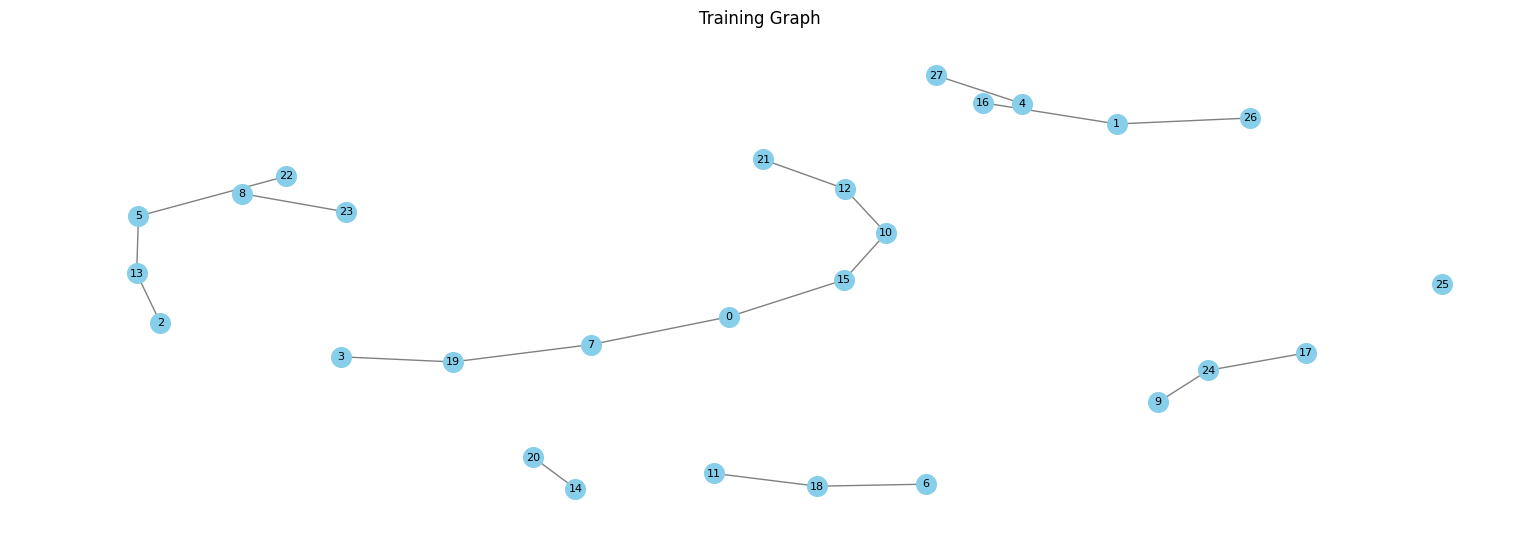

[0, 1, 2, 3, 4, 5, 6, 7, 8]


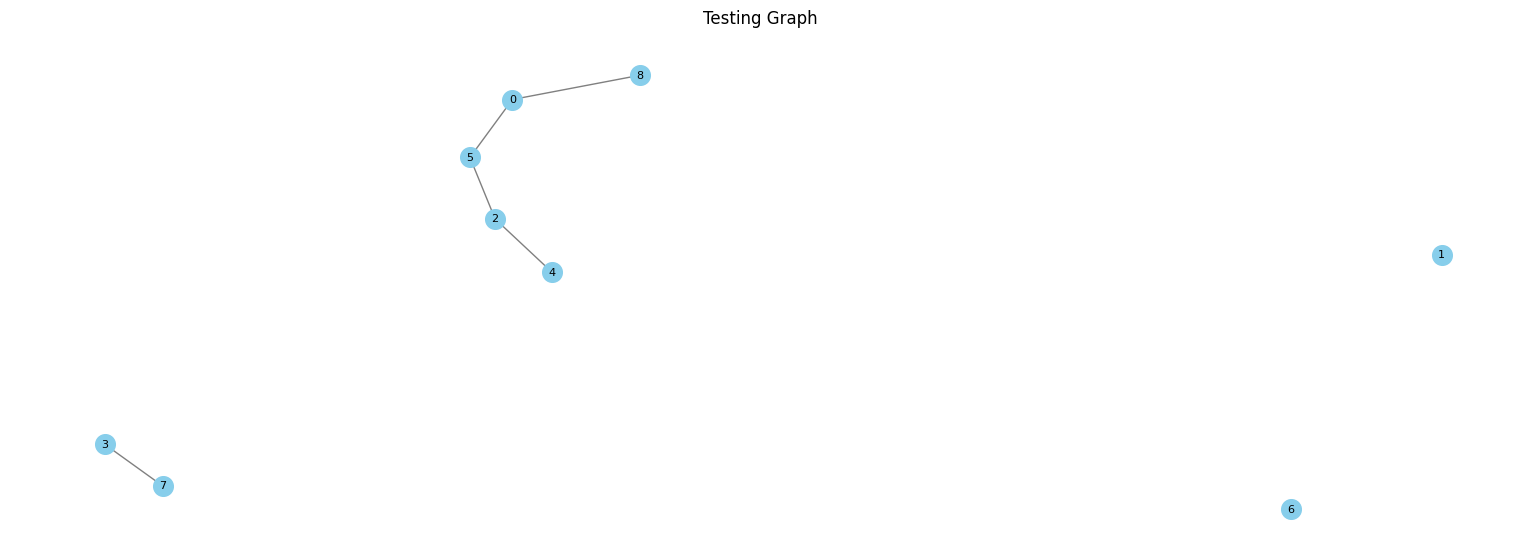

[0, 1, 2, 3, 4, 5, 6]


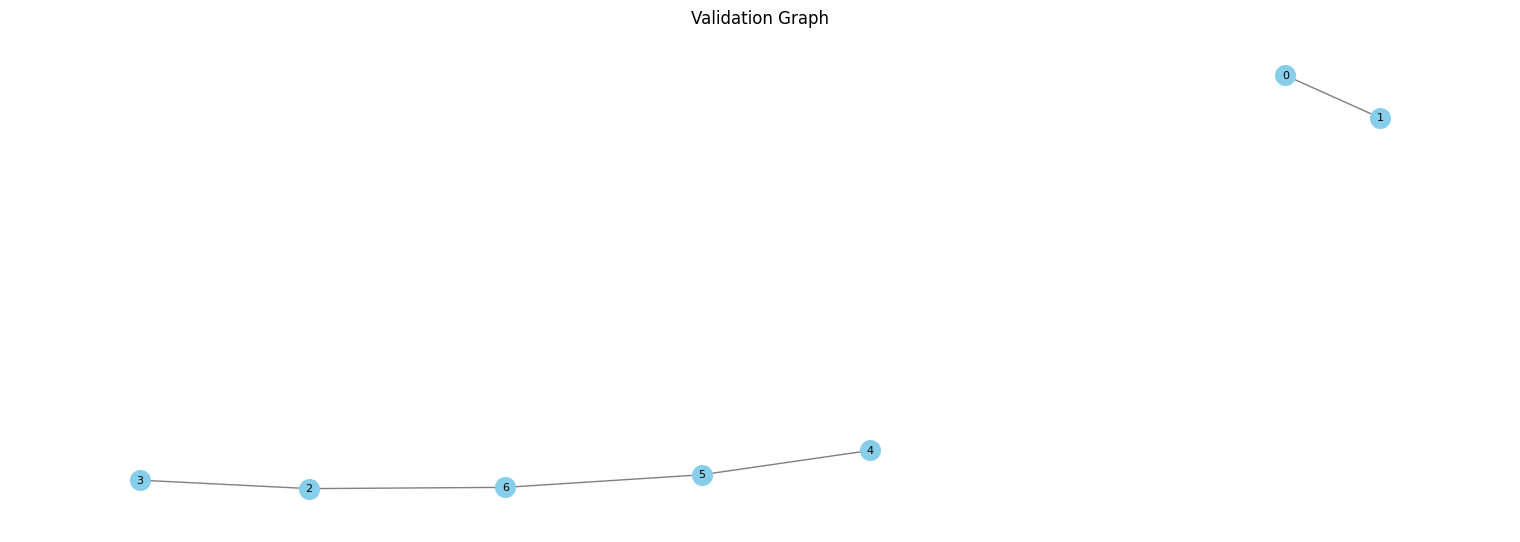

In [10]:
# Visualizing Train Graph
visualize_graph(train_data, title="Training Graph")

# Visualizing Test Graph
visualize_graph(test_data, title="Testing Graph")

visualize_graph(val_data, title="Validation Graph")


## Training and evaluating loss & accuracy

Epoch 1/350, Train Loss: 15.235424995422363, Train Accuracy: 8.561744689941406%
Val Loss: 16.218353271484375, Val Accuracy: 7.280296325683594%
Epoch 2/350, Train Loss: 15.21150016784668, Train Accuracy: 9.760948181152344%
Val Loss: 16.195283889770508, Val Accuracy: 8.012397766113281%
Epoch 3/350, Train Loss: 15.186897277832031, Train Accuracy: 10.930984497070312%
Val Loss: 16.17083740234375, Val Accuracy: 8.772048950195312%
Epoch 4/350, Train Loss: 15.160740852355957, Train Accuracy: 12.172035217285156%
Val Loss: 16.1447811126709, Val Accuracy: 9.598457336425781%
Epoch 5/350, Train Loss: 15.1322021484375, Train Accuracy: 13.526542663574219%
Val Loss: 16.116558074951172, Val Accuracy: 10.517524719238281%
Epoch 6/350, Train Loss: 15.10045337677002, Train Accuracy: 15.031143188476562%
Val Loss: 16.085845947265625, Val Accuracy: 11.5556640625%
Epoch 7/350, Train Loss: 15.064976692199707, Train Accuracy: 16.751869201660156%
Val Loss: 16.051549911499023, Val Accuracy: 12.813339233398438%
Epo

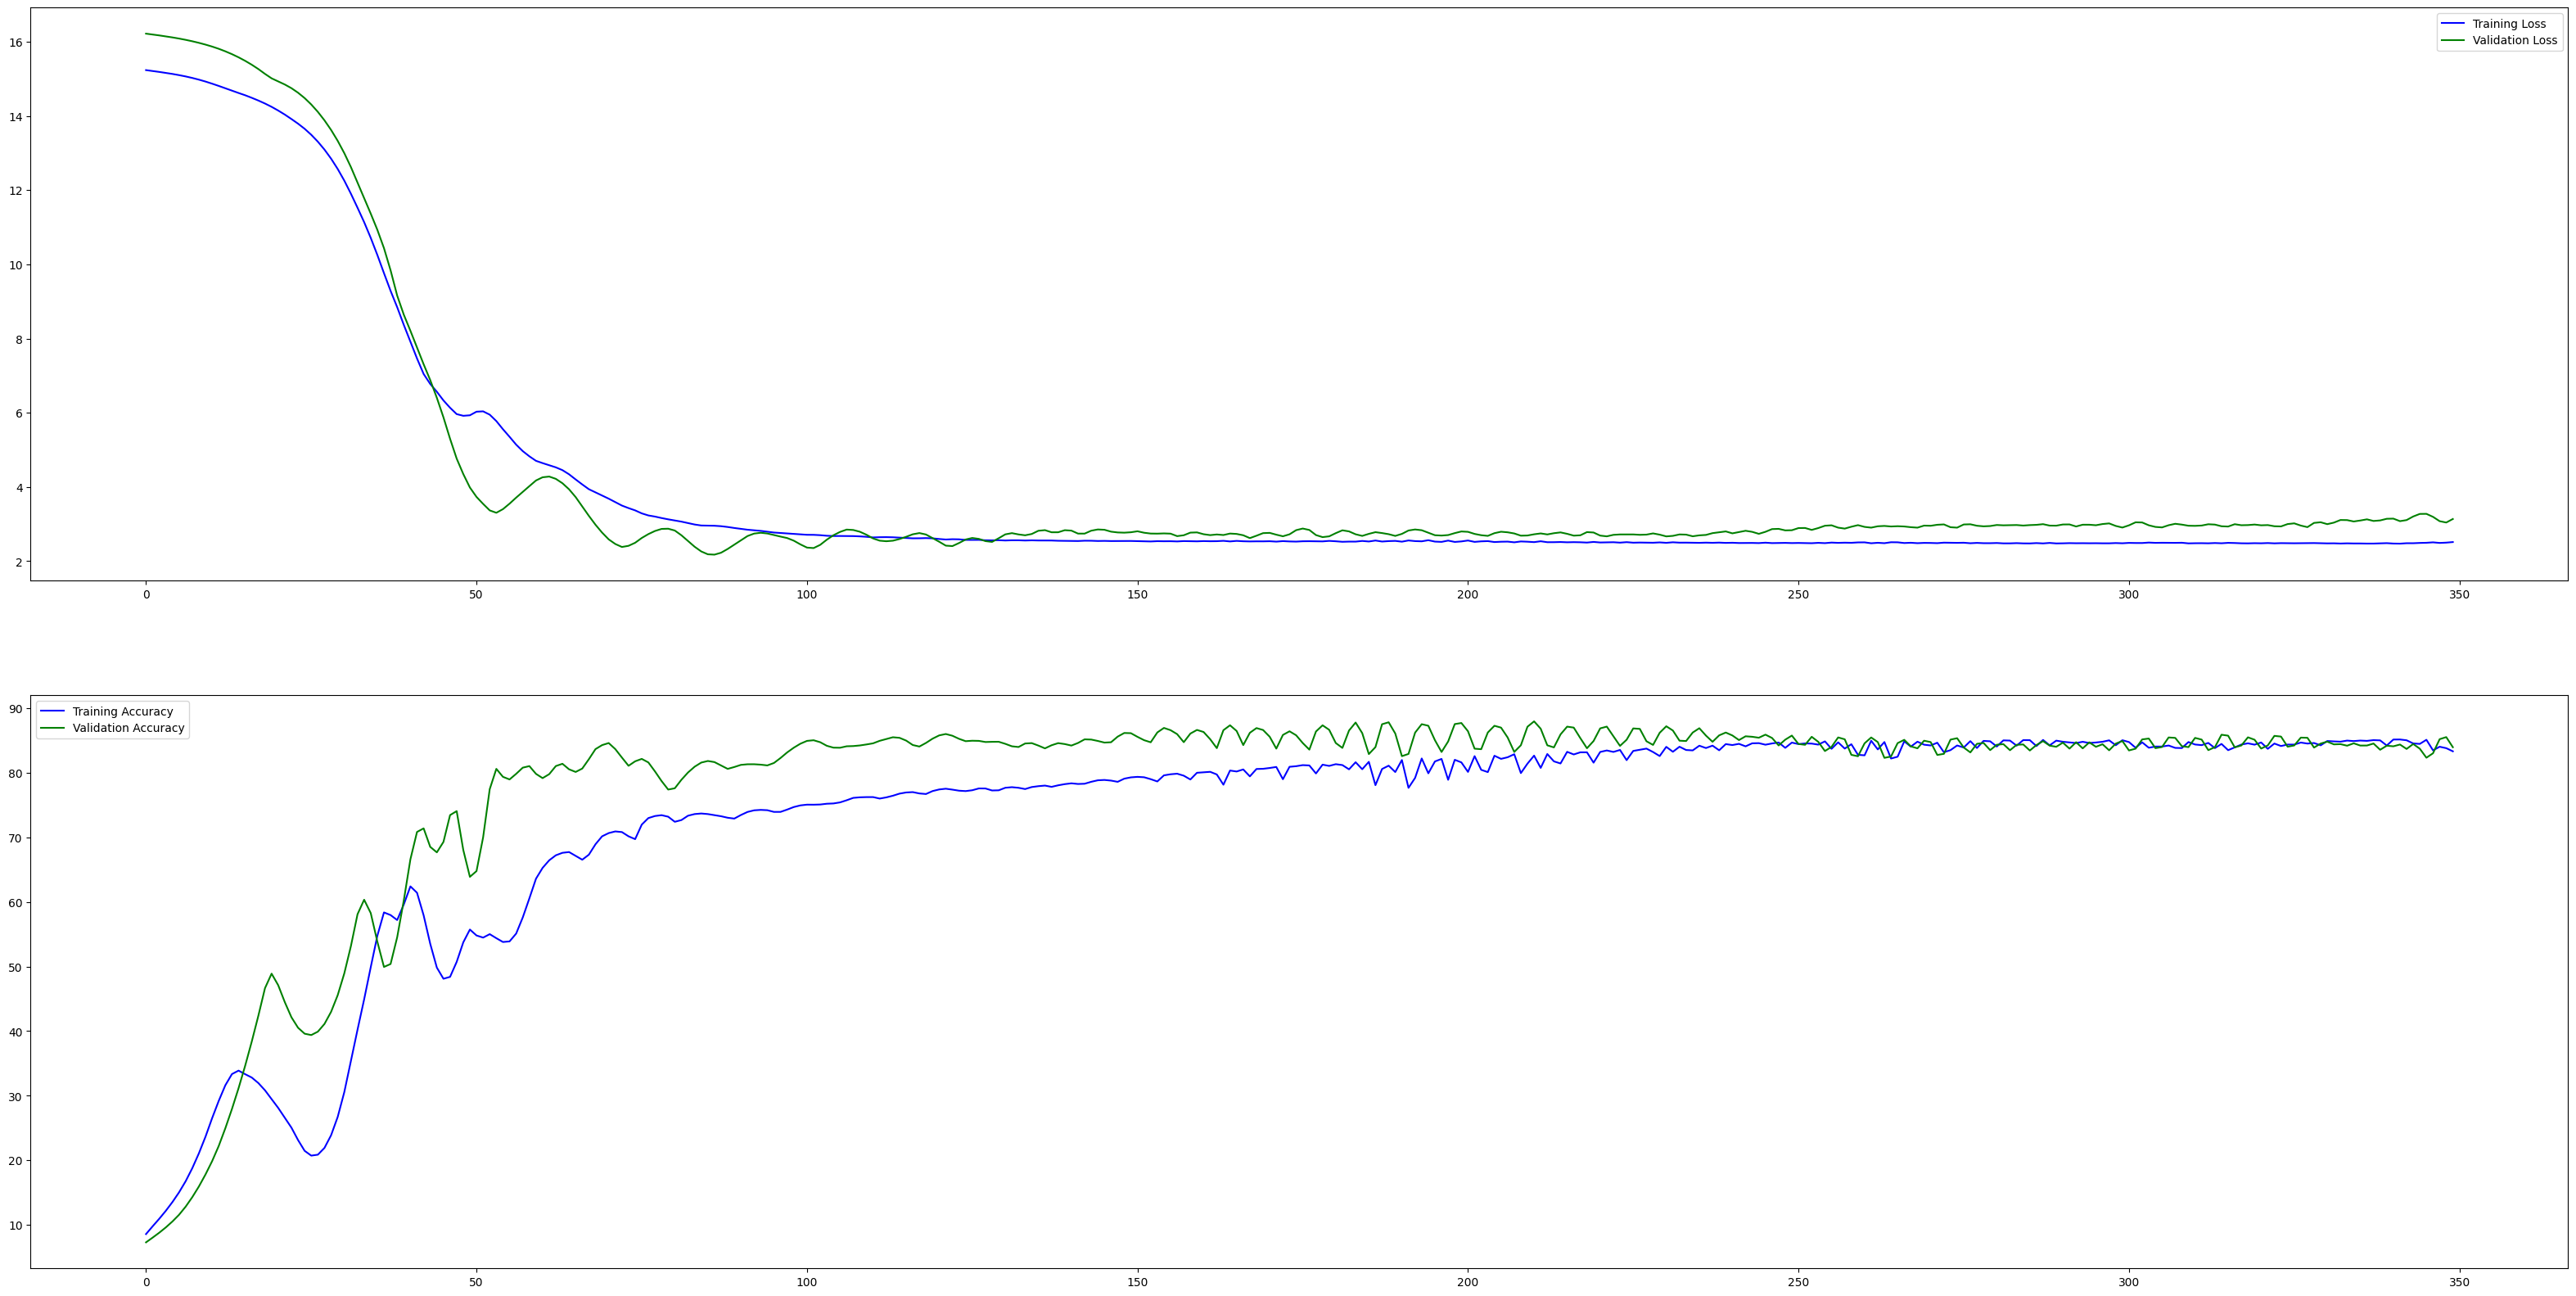

In [11]:
# Train the model
model = KneePointGCN(features=10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.L1Loss()
epochs = 350
hist = train(model=model, train_data=train_data, val_data=val_data, test_data=test_data, optimizer=optimizer, loss_fn=loss_fn, epochs=epochs)
plot_losses(training_losses=hist['train_losses'], training_accuracies=hist['train_accuracies'], test_accuracies=hist['test_accuracies'], test_losses=hist['test_losses'], val_accuracies=hist['val_accuracies'], val_losses=hist['val_losses'], epochs=epochs, save_path='/home/sgl57/CSE_MSE_RXF131/cradle-members/mds3/sgl57/24-ceramics-rishi/topics/GNN')